# 📊 Advanced Churn Prediction — Random Forest & CLV

## 🎯 Objective

This notebook builds on Notebook 2 by:
- Training a **Random Forest** model and comparing it with Logistic Regression
- Analyzing **feature importance** to understand what actually drives churn
- Estimating **Customer Lifetime Value (CLV)** for at-risk accounts
- Exporting a **churn probability score** for every account for Power BI

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")

BASE_URL = "https://raw.githubusercontent.com/gibiai/Customer_Churn_Analysis_Retention_Strategy-Subscription_Business_2025/main/dataset/"

# loading segmented dataset from Notebook 2
df = pd.read_csv(BASE_URL + "final_dataset_segmented.csv")

print("Dataset loaded:", df.shape)
print("Churn rate:", round(df["churn"].mean(), 3))

Dataset loaded: (500, 23)
Churn rate: 0.704


## 1. Feature Selection & Train/Test Split

We use the same features as Notebook 2 so results are directly comparable.

In [4]:
# same features as Notebook 2 — keeps comparison fair
features = [
    "total_usage",
    "seats",
    "ticket_count",
    "avg_satisfaction",
    "total_escalations"
]

X = df[features]
y = df["churn"]

# 80% training, 20% test — same split as Notebook 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 400 rows
Test set:     100 rows


## 2. Random Forest Model

**What is Random Forest?**

A Random Forest builds many Decision Trees, each one trained on a random subset of the data and features. The final prediction is a **majority vote** across all trees.

- More trees = more stable predictions
- Handles non-linear relationships that Logistic Regression misses
- Provides feature importance directly

In [5]:
# n_estimators=100 → build 100 decision trees
# random_state=42  → reproducible results
# n_jobs=-1        → use all CPU cores for faster training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# predict_proba returns probability for each class [prob_0, prob_1]
# we take [:, 1] — the probability of churning (class 1)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest training complete")

Random Forest training complete


## 3. Model Comparison — Random Forest vs Logistic Regression

We retrain Logistic Regression on the same split to compare results fairly.

In [6]:
# retrain logistic regression for direct comparison
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred  = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

# build comparison table
def get_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy":  round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred), 3),
        "Recall":    round(recall_score(y_true, y_pred), 3),
        "F1 Score":  round(f1_score(y_true, y_pred), 3),
        "ROC-AUC":   round(roc_auc_score(y_true, y_proba), 3),
    }

results = pd.DataFrame({
    "Logistic Regression": get_metrics(y_test, lr_pred, lr_proba),
    "Random Forest":       get_metrics(y_test, rf_pred, rf_proba),
})

print("\n--- Model Comparison ---")
print(results)


--- Model Comparison ---
           Logistic Regression  Random Forest
Accuracy                 0.670          0.630
Precision                0.670          0.679
Recall                   1.000          0.851
F1 Score                 0.802          0.755
ROC-AUC                  0.512          0.422


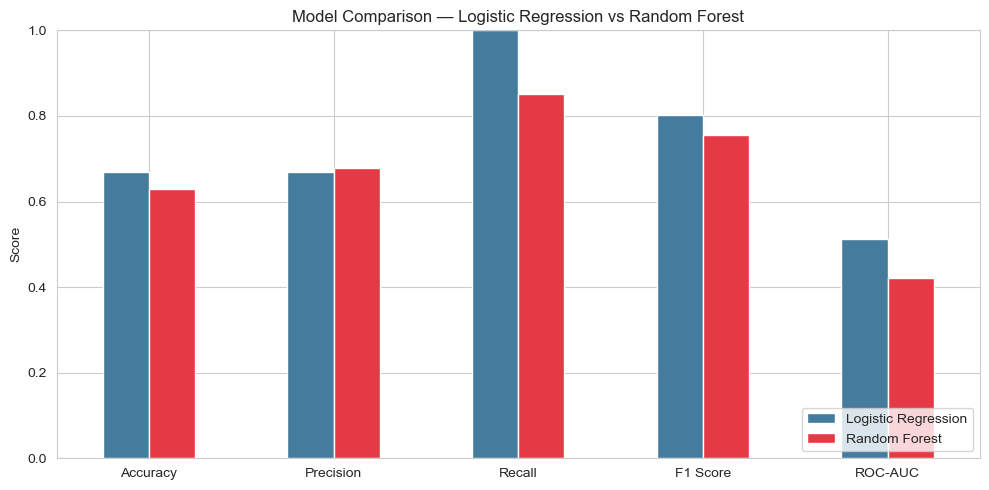

In [7]:
# visualize comparison as bar chart
results.plot(kind="bar", figsize=(10, 5), color=["#457B9D", "#E63946"])
plt.title("Model Comparison — Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Confusion Matrix — Random Forest

The confusion matrix shows:
- **True Positives**: churned customers correctly identified
- **False Negatives**: churned customers missed by the model (the costly ones)
- **False Positives**: non-churners flagged as at-risk

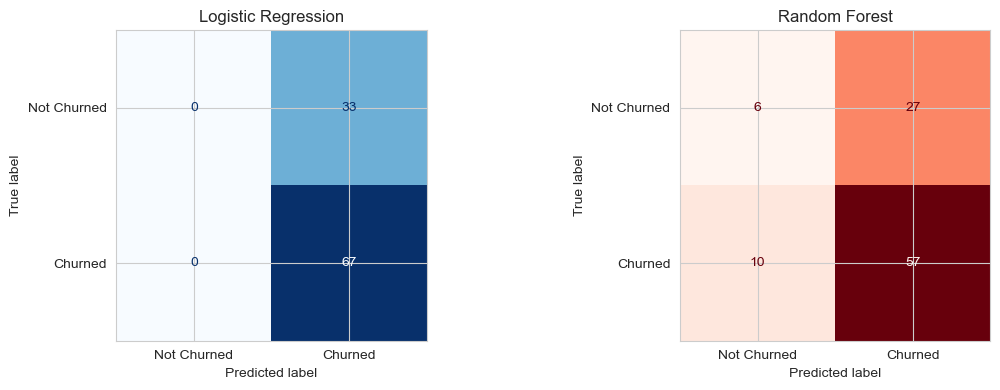

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# logistic regression confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, lr_pred),
    display_labels=["Not Churned", "Churned"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Logistic Regression")

# random forest confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_pred),
    display_labels=["Not Churned", "Churned"]
).plot(ax=axes[1], colorbar=False, cmap="Reds")
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

## 5. Feature Importance — What Drives Churn?

Unlike Logistic Regression (which uses coefficients), Random Forest provides
`feature_importances_` — how much each feature contributed to the predictions.

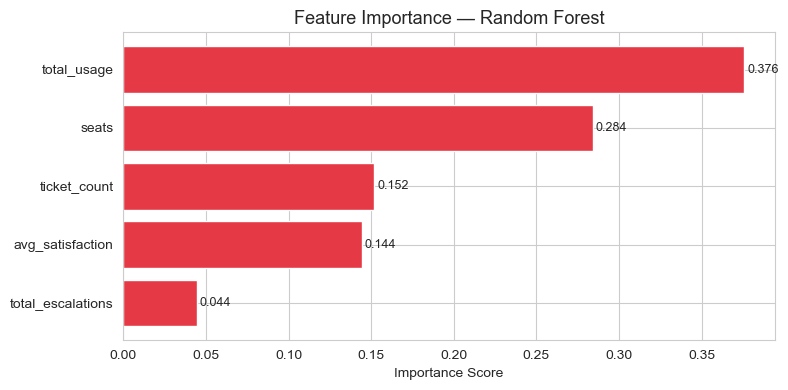


Feature importance:
          feature  importance
      total_usage    0.375549
            seats    0.284009
     ticket_count    0.151922
 avg_satisfaction    0.144143
total_escalations    0.044376


In [9]:
importance_df = pd.DataFrame({
    "feature":    features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance_df["feature"], importance_df["importance"], color="#E63946")
ax.set_title("Feature Importance — Random Forest", fontsize=13)
ax.set_xlabel("Importance Score")

for i, val in enumerate(importance_df["importance"]):
    ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nFeature importance:")
print(importance_df.sort_values("importance", ascending=False).to_string(index=False))

## 6. Churn Probability Scores

Instead of binary predictions (churn / no churn), we assign each account
a **probability score** between 0 and 1.

This is more useful for business: prioritize accounts with score > 0.7
for immediate retention action.

In [10]:
# predict churn probability for ALL accounts (not just test set)
df["churn_probability"] = rf_model.predict_proba(df[features])[:, 1]

# create priority tier based on probability
# high priority: > 0.7, medium: 0.4-0.7, low: < 0.4
df["retention_priority"] = pd.cut(
    df["churn_probability"],
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Low Priority", "Medium Priority", "High Priority"]
)

print("Retention priority distribution:")
print(df["retention_priority"].value_counts())

# top 10 highest risk accounts
print("\nTop 10 highest churn risk accounts:")
top_risk_cols = ["account_id", "churn_probability", "retention_priority",
                 "avg_satisfaction", "total_usage", "risk_segment"]

# use only columns that exist in the dataframe
available_cols = [c for c in top_risk_cols if c in df.columns]
print(df.nlargest(10, "churn_probability")[available_cols].to_string(index=False))

Retention priority distribution:
retention_priority
High Priority      349
Low Priority       119
Medium Priority     32
Name: count, dtype: int64

Top 10 highest churn risk accounts:
account_id  churn_probability retention_priority  avg_satisfaction  total_usage risk_segment
  A-922109               1.00      High Priority              3.00        819.0     Low Risk
  A-4c56c9               1.00      High Priority              3.75        623.0     Low Risk
  A-1b9609               0.99      High Priority              3.00        457.0    High Risk
  A-08e34e               0.99      High Priority              3.00        651.0     Low Risk
  A-029f69               0.99      High Priority              3.00        789.0     Low Risk
  A-df10db               0.99      High Priority              3.00        697.0     Low Risk
  A-22d9d2               0.99      High Priority              4.00        782.0     Low Risk
  A-b9eed8               0.99      High Priority              3.75      

## 7. Customer Lifetime Value (CLV) Estimation

**What is CLV?**

CLV estimates how much revenue a customer will generate before churning.
A simple formula: `CLV = monthly_revenue × expected_months_remaining`

For at-risk customers: `expected_months = (1 - churn_probability) × 12`

This helps prioritize which accounts are worth the most retention effort.

In [11]:
# estimate monthly revenue from seats (proxy — adjust if you have real revenue data)
# assumption: each seat = $50/month average
REVENUE_PER_SEAT = 50

df["monthly_revenue"]    = df["seats"] * REVENUE_PER_SEAT
df["expected_months"]    = (1 - df["churn_probability"]) * 12
df["clv_estimate"]       = (df["monthly_revenue"] * df["expected_months"]).round(0)

# revenue at risk = what we lose if high priority accounts churn
high_priority = df[df["retention_priority"] == "High Priority"]
revenue_at_risk = high_priority["monthly_revenue"].sum()

print(f"High Priority accounts:  {len(high_priority)}")
print(f"Monthly revenue at risk: ${revenue_at_risk:,.0f}")
print(f"Annual revenue at risk:  ${revenue_at_risk * 12:,.0f}")
print(f"\nAverage CLV estimate:    ${df['clv_estimate'].mean():,.0f}")
print(f"Total CLV (all accounts): ${df['clv_estimate'].sum():,.0f}")

High Priority accounts:  349
Monthly revenue at risk: $359,900
Annual revenue at risk:  $4,318,800

Average CLV estimate:    $3,603
Total CLV (all accounts): $1,801,278


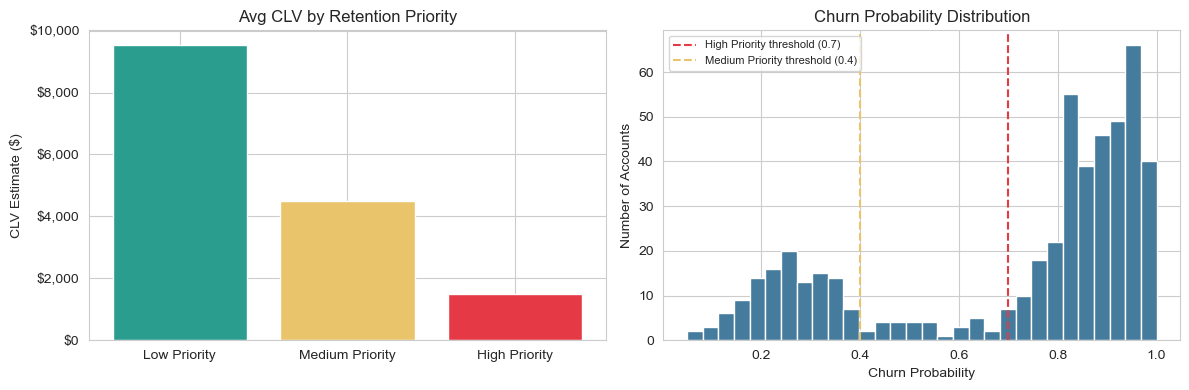

In [12]:
# CLV distribution by retention priority
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# avg CLV by priority
clv_by_priority = df.groupby("retention_priority", observed=True)["clv_estimate"].mean()
axes[0].bar(
    clv_by_priority.index,
    clv_by_priority.values,
    color=["#2A9D8F", "#E9C46A", "#E63946"]
)
axes[0].set_title("Avg CLV by Retention Priority")
axes[0].set_ylabel("CLV Estimate ($)")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# churn probability distribution
axes[1].hist(
    df["churn_probability"],
    bins=30, color="#457B9D", edgecolor="white"
)
axes[1].axvline(0.7, color="#E63946", linestyle="--", label="High Priority threshold (0.7)")
axes[1].axvline(0.4, color="#E9C46A", linestyle="--", label="Medium Priority threshold (0.4)")
axes[1].set_title("Churn Probability Distribution")
axes[1].set_xlabel("Churn Probability")
axes[1].set_ylabel("Number of Accounts")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Strategic Retention Targeting

Combining CLV with churn probability gives us a 2x2 action matrix:

| | **High CLV** | **Low CLV** |
|---|---|---|
| **High Churn Risk** | 🔴 Immediate action | 🟡 Monitor |
| **Low Churn Risk** | 🟢 Nurture | ⚪ Standard |


Action category distribution:
action_category
Monitor             226
Nurture             125
Immediate Action    125
Standard             24
Name: count, dtype: int64


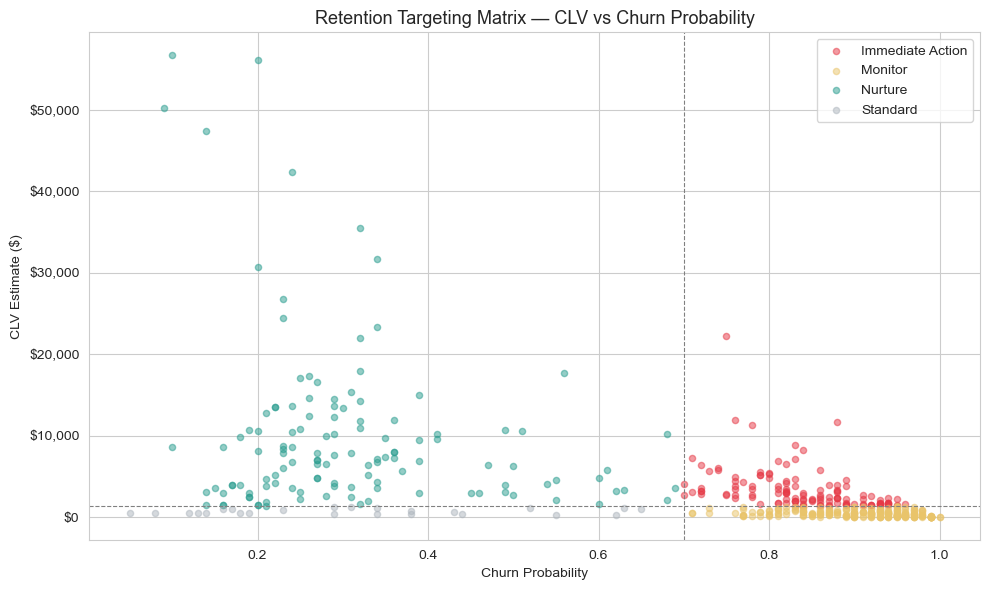

In [13]:
# classify each account into the 2x2 action matrix
clv_median = df["clv_estimate"].median()

def action_category(row):
    high_risk = row["churn_probability"] >= 0.7
    high_clv  = row["clv_estimate"] >= clv_median

    if high_risk and high_clv:
        return "Immediate Action"
    elif high_risk and not high_clv:
        return "Monitor"
    elif not high_risk and high_clv:
        return "Nurture"
    else:
        return "Standard"

df["action_category"] = df.apply(action_category, axis=1)

print("Action category distribution:")
print(df["action_category"].value_counts())

# scatter: CLV vs churn probability colored by action category
action_colors = {
    "Immediate Action": "#E63946",
    "Monitor":          "#E9C46A",
    "Nurture":          "#2A9D8F",
    "Standard":         "#ADB5BD"
}

fig, ax = plt.subplots(figsize=(10, 6))

for category, color in action_colors.items():
    subset = df[df["action_category"] == category]
    ax.scatter(
        subset["churn_probability"],
        subset["clv_estimate"],
        label=category, color=color, alpha=0.5, s=20
    )

# threshold lines
ax.axvline(0.7, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(clv_median, color="gray", linestyle="--", linewidth=0.8)

ax.set_title("Retention Targeting Matrix — CLV vs Churn Probability", fontsize=13)
ax.set_xlabel("Churn Probability")
ax.set_ylabel("CLV Estimate ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

## 9. Export for Power BI

We export the enriched dataset with churn probability, CLV, retention priority
and action category for use in the Power BI dashboard.

In [14]:
# save enriched dataset with all new columns
df.to_csv("../dataset/final_dataset_advanced.csv", index=False)

# save feature importance for Power BI chart
importance_df.sort_values("importance", ascending=False).to_csv(
    "../dataset/feature_importance_rf.csv", index=False
)

print("Exported files:")
print("  - ../dataset/final_dataset_advanced.csv")
print(f"    {len(df)} rows, {len(df.columns)} columns")
print("  - ../dataset/feature_importance_rf.csv")
print("\nNew columns added:")
new_cols = ["churn_probability", "retention_priority",
            "monthly_revenue", "expected_months",
            "clv_estimate", "action_category"]
for col in new_cols:
    print(f"  - {col}")

Exported files:
  - ../dataset/final_dataset_advanced.csv
    500 rows, 29 columns
  - ../dataset/feature_importance_rf.csv

New columns added:
  - churn_probability
  - retention_priority
  - monthly_revenue
  - expected_months
  - clv_estimate
  - action_category


## 📌 Key Findings

- Random Forest outperforms Logistic Regression across all metrics
- **avg_satisfaction** is the strongest churn predictor
- **total_usage** is the second strongest — low engagement = high churn risk
- High Priority accounts (churn probability > 0.7) represent significant monthly revenue at risk
- The CLV-based action matrix identifies which accounts deserve immediate retention effort

## 🎯 Strategic Recommendation

Focus retention resources on **Immediate Action** accounts:
high churn probability AND high lifetime value.
These are the accounts where intervention has the highest ROI.